In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

# Task 1

Давай загрузим датасет CIFAR-10. Допиши функцию [load_dataloaders](./code-samples/cv_utils.py) с помощью [torchvision.datasets.CIFAR10](https://pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html)
и [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader), чтобы функция возвращала
DataLoaderы для train и test частей датасета. \
C помощью функции `len` количество батчей в train_loader и test_loader.
> Для тестового DataLoader укажите параметр `shuffle=False`, параметры `transform` и `batch_size` оставьте по умолчанию.

In [2]:
BASE_TRANSFORM = transforms.Compose(
    [
        # Перевод изображений в тензоры
        transforms.ToTensor(),
        # Переводим цвета пикселей в отрезок [-1, 1]
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)
BATCH_SIZE = 64 # Количество изображений в Батче
CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck') # Классы CIFAR10

In [3]:
def load_dataloaders(transform=BASE_TRANSFORM, batch_size=BATCH_SIZE):
    train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=False, num_workers=2)
    # Код тут
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    
    return train_loader, test_loader

In [4]:
train_loader, test_loader = load_dataloaders()

Files already downloaded and verified
Files already downloaded and verified


In [5]:
print(f"Количество изображений в тренировачной выборке: {len(train_loader)}")
print(f"Количество изображений в тестовой выборке: {len(test_loader)}")

Количество изображений в тренировачной выборке: 782
Количество изображений в тестовой выборке: 157


# Task 2

Узнай, как из объекта DataLoader можно получить изображения и метки. \
Передай первые 4 изображения и метки из первого батча тестовой выборки в функцию [imshow](./code-samples/cv_utils.py).
С помощью нее можно визуализировать датасет. \
Должна получиться примерно такая визуализация.
![sample](../misc/images/images_sample.png)
> Картинки и метки могут отличаться. Главное чтобы метки сходились с изображениями)

In [6]:
def imshow(images, labels, padding_size=15, labels_split_size=25):
    img = torchvision.utils.make_grid(images)
    # убрать нормализацию
    img = img / 2 + 0.5    
    npimg = img.numpy()
    label_text = (' ' * labels_split_size).join('{}'.format(CLASSES[j]) for j in labels.tolist())
    print(' ' * padding_size + label_text)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [7]:
images, labels = iter(test_loader).next()
images, labels = images[:4], labels[:4]

               cat                         ship                         ship                         plane


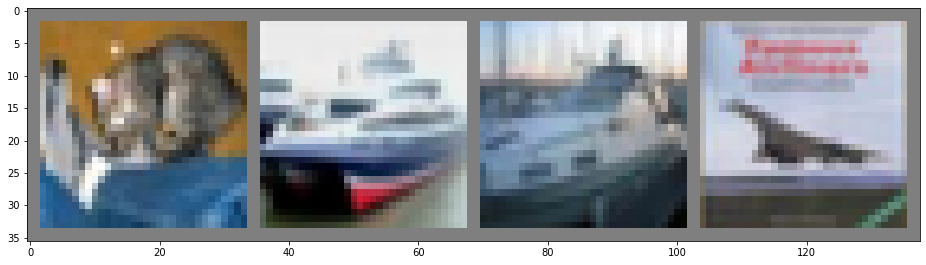

In [8]:
plt.figure(figsize=(16, 9))
imshow(images, labels)

# Task 3

Теперь попробуем написать небольшую сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Напишем сеть, основанную на одном блоке архитектуры [ResNet](https://arxiv.org/pdf/1512.03385.pdf) - Residual-Block. Схема этого блока приведена ниже:

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

Допишите класс ResidualNet:
- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Также в сверточных слоях `padding = 1`

Функции, которые вам понадобяться: 
[Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [BatchNorm2d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html), [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html).

Для базовой проверки, что сеть написана верно этот код не должен выдавать ошибку\
`assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)`

In [9]:
class ResidualNet(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.conv_3 = nn.Conv2d(3, 32, 1)

        self.residual_block = nn.Sequential( 
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32)
        )

        self.clf = nn.Sequential(
            nn.ReLU(),
            nn.AvgPool2d(8),
            nn.Flatten(1),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):

        out = self.residual_block(x)
        out += self.conv_3(x)
        out = self.clf(out)

        return out

In [10]:
net = ResidualNet(n_classes=10)

In [11]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

# Task 4

In [12]:
class Trainer:
    
    def __init__(self, model, optimizer, criterion):
        self.model = model
        self.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        self.model = self.model.to(self.device)
        print('Сеть загружена на', self.device)
        
        self.optimizer = optimizer
        self.criterion = criterion

    def _train_epoch(self, train_loader):
        loss_log = []
        acc_log = []
        self.model.train()
        
        for data, target in train_loader:
            data = data.to(self.device)
            target = target.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(data)

            loss = self.criterion(logits, target)
            loss.backward()
            self.optimizer.step()

            loss_log.append(loss.item() * data.shape[0])

            acc = (logits.argmax(dim=1) == target).sum()
            acc_log.append(acc.item() / data.shape[0]) 

        return np.mean(loss_log), np.mean(acc_log)

    def train(self, train_loader, test_loader, n_epochs):
        
        self.train_loss_log = [] 
        self.train_acc_log = [] 
        self.test_loss_log = []
        self.test_acc_log = []
        
        for epoch in range(n_epochs):
            train_loss, train_acc = self._train_epoch(train_loader)
            test_loss, test_acc = self.test(test_loader)

            self.train_loss_log.append(train_loss)
            self.train_acc_log.append(train_acc)

            self.test_loss_log.append(test_loss)
            self.test_acc_log.append(test_acc)

            print(f"Epoch {epoch}")
            print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
            print(f" test loss: {test_loss}, test acc: {test_acc}\n")
    
    def test(self, test_loader):
        loss_log = []
        acc_log = []
        self.model.eval()

        for data, target in test_loader:
            data = data.to(self.device)
            target = target.to(self.device)

            with torch.no_grad():
                logits = self.model(data)
                loss = self.criterion(logits, target)

            loss_log.append(loss.item() * data.shape[0])

            acc = (logits.argmax(dim=1) == target).sum()
            acc_log.append(acc.item() / data.shape[0]) 

        return np.mean(loss_log), np.mean(acc_log)

In [13]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
criterion = nn.CrossEntropyLoss()
        
trainer = Trainer(net, optimizer, criterion)

Сеть загружена на cuda:0


In [14]:
trainer.train(train_loader, test_loader, 5)

Epoch 0
 train loss: 88.29332185096447, train acc: 0.5105099104859335
 test loss: 71.95774656648089, test acc: 0.6100716560509554

Epoch 1
 train loss: 68.26734438210802, train acc: 0.6300351662404092
 test loss: 64.72510096070114, test acc: 0.6474920382165605

Epoch 2
 train loss: 62.966782969891874, train acc: 0.6587476023017903
 test loss: 62.218867581361415, test acc: 0.6590366242038217

Epoch 3
 train loss: 59.96036944425929, train acc: 0.6767503196930946
 test loss: 60.447592231118755, test acc: 0.6698845541401274

Epoch 4
 train loss: 57.74043201241652, train acc: 0.6874800191815856
 test loss: 59.0490749869377, test acc: 0.6780453821656051



In [15]:
def plot_train_log(trainer):
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))

    axs[0].plot(range(1, len(trainer.train_loss_log) + 1), trainer.train_loss_log, label='train')
    axs[0].plot(range(1, len(trainer.test_loss_log) + 1), trainer.test_loss_log, label='test')
    axs[0].set_ylabel('Loss')

    axs[1].plot(range(1, len(trainer.train_acc_log) + 1), trainer.train_acc_log, label='train')
    axs[1].plot(range(1, len(trainer.test_acc_log) + 1), trainer.test_acc_log, label='test')
    axs[1].set_ylabel('Accuracy')

    for ax in axs:
        ax.set_xlabel('Epoch')
        ax.legend()

    plt.show()

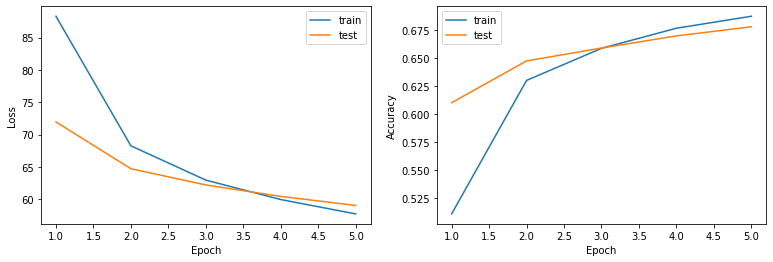

In [16]:
plot_train_log(trainer)

# Task 5

In [36]:
transform_v2 = transforms.Compose(
        [
            transforms.ColorJitter(brightness=.1, hue=.1),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]
)

In [37]:
train_loader_v2, test_loader_v2 = load_dataloaders(transform=transform_v2)

Files already downloaded and verified
Files already downloaded and verified


In [38]:
images, labels = iter(test_loader).next()
images, labels = images[:4], labels[:4]

               cat                         ship                         ship                         plane


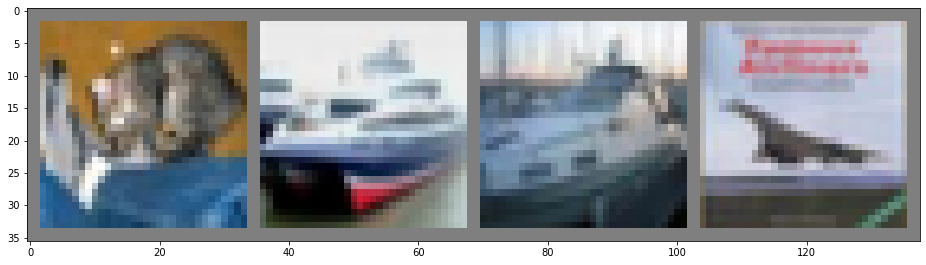

In [39]:
plt.figure(figsize=(16, 9))
imshow(images, labels)

In [40]:
images, labels = iter(test_loader_v2).next()
images, labels = images[:4], labels[:4]

               cat                         ship                         ship                         plane


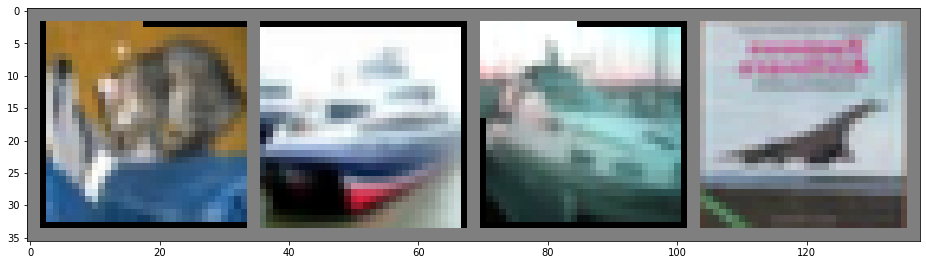

In [41]:
plt.figure(figsize=(16, 9))
imshow(images, labels)

In [34]:
images, labels = iter(test_loader_v2).next()
images, labels = images[:4], labels[:4]

In [35]:
net_2 = ResidualNet(n_classes=10)
net_2

ResidualNet(
  (conv_3): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (residual_block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (clf): Sequential(
    (0): ReLU()
    (1): AvgPool2d(kernel_size=8, stride=8, padding=0)
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [25]:
optimizer = optim.SGD(net_2.parameters(), lr=0.1, momentum=0.9)

trainer_2 = Trainer(net_2, optimizer, criterion)

Сеть загружена на cuda:0


In [26]:
trainer_2.train(train_loader, test_loader, 5)

Epoch 0
 train loss: 92.30290014359652, train acc: 0.48787164322250637
 test loss: 75.11355774265945, test acc: 0.5840963375796179

Epoch 1
 train loss: 71.4520850120603, train acc: 0.6111333120204604
 test loss: 68.39310486908931, test acc: 0.620421974522293

Epoch 2
 train loss: 65.2163218988482, train acc: 0.6451406649616368
 test loss: 63.47593117975126, test acc: 0.6491839171974523

Epoch 3
 train loss: 61.98415538417104, train acc: 0.6620244565217391
 test loss: 62.07952079651462, test acc: 0.6587380573248408

Epoch 4
 train loss: 59.71224182158175, train acc: 0.675471547314578
 test loss: 60.694615528082394, test acc: 0.6734673566878981



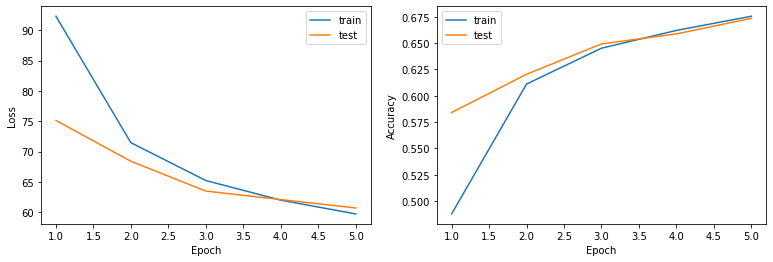

In [27]:
plot_train_log(trainer_2)